<center><h1>Школа глубокого обучения ФПМИ МФТИ</h1></center>

<center>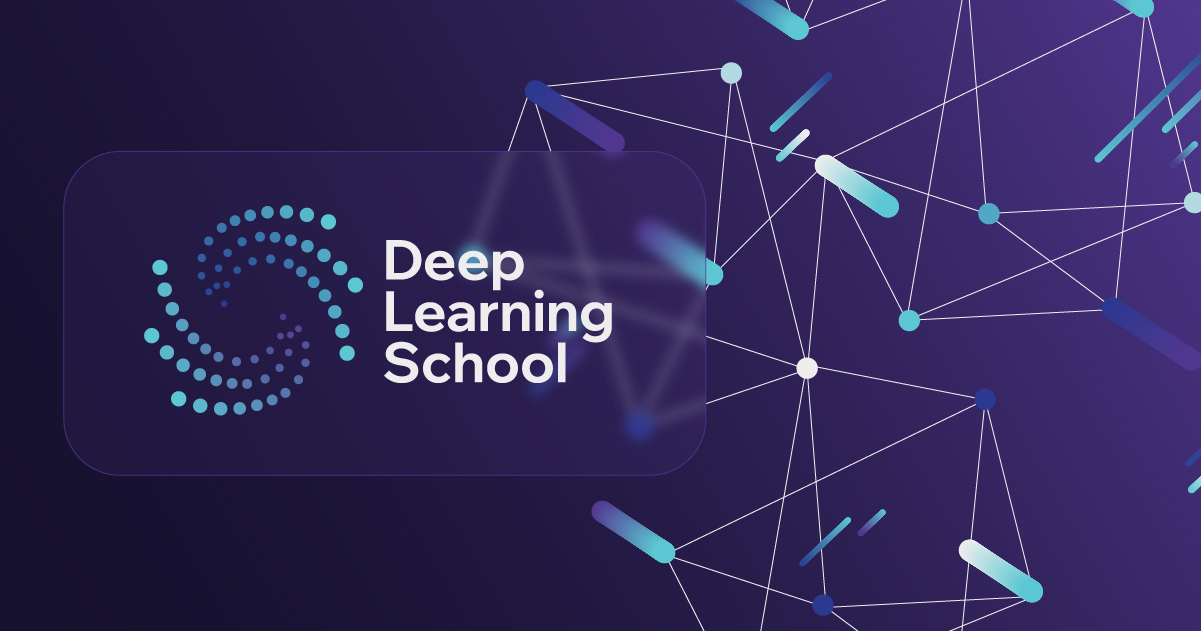</center>

<center><h1>Домашнее задание: Генеративно-состязательные сети.</h1></center>

В этом домашнем задании вы обучите GAN генерировать лица людей и посмотрите на то, как можно оценивать качество генерации.

In [ ]:
%matplotlib inline

In [ ]:
import os
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as tt
import torch
import torch.nn as nn
import cv2

from tqdm.notebook import tqdm
from torchvision.utils import save_image
from torchvision.utils import make_grid

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='darkgrid', font_scale=1.2)

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Используется устройство: {device}')

Используется устройство: cuda


## Часть 1: Подготовка данных

В качестве обучающей выборки возьмем часть датасета <a href="https://github.com/NVlabs/ffhq-dataset">Flickr Faces</a>, который содержит изображения лиц людей в высоком разрешении ($1024 \times 1024$). Оригинальный датасет очень большой, поэтому мы возьмем его часть. Скачать датасет можно из <a href="https://www.kaggle.com/datasets/tommykamaz/faces-dataset-small?resource=download-directory">Kaggle</a> и/или из Google Drive напрямую в Jupyter Notebook:

In [ ]:
!pip install --no-cache-dir --default-timeout=1000 --quiet --disable-pip-version-check -q -q gdown

In [ ]:
!gdown 1fp43y-iONbdI-Hh5Q_wEnhUPjZsTADue

Downloading...
From (original): https://drive.google.com/uc?id=1fp43y-iONbdI-Hh5Q_wEnhUPjZsTADue
From (redirected): https://drive.google.com/uc?id=1fp43y-iONbdI-Hh5Q_wEnhUPjZsTADue&confirm=t&uuid=41910826-efad-437b-ba43-121e16ad9942
To: c:\Users\Admin\Desktop\Homework\dataset.zip

  0%|          | 0.00/4.28G [00:00<?, ?B/s]
  0%|          | 524k/4.28G [00:00<44:19, 1.61MB/s]
  0%|          | 1.57M/4.28G [00:00<18:13, 3.91MB/s]
  0%|          | 2.62M/4.28G [00:00<23:43, 3.01MB/s]
  0%|          | 3.67M/4.28G [00:01<18:47, 3.79MB/s]
  0%|          | 5.24M/4.28G [00:01<12:54, 5.52MB/s]
  0%|          | 6.29M/4.28G [00:01<11:52, 6.00MB/s]
  0%|          | 7.34M/4.28G [00:01<11:17, 6.31MB/s]
  0%|          | 8.39M/4.28G [00:01<10:49, 6.58MB/s]
  0%|          | 9.44M/4.28G [00:01<10:31, 6.77MB/s]
  0%|          | 10.5M/4.28G [00:01<10:16, 6.93MB/s]
  0%|          | 11.5M/4.28G [00:02<10:09, 7.01MB/s]
  0%|          | 12.6M/4.28G [00:02<10:03, 7.07MB/s]
  0%|          | 13.6M/4.28G [00:02<10:

In [ ]:
import zipfile

# Распаковка архива
with zipfile.ZipFile('dataset.zip', 'r') as archive:
    archive.extractall('.')

In [ ]:
import os

# Просмотр содержимого архива
print(os.listdir('dataset'))

['00055.png', '00237.png', '00240.png', '00241.png', '00242.png', '00243.png', '00244.png', '00245.png', '00246.png', '00247.png', '00248.png', '00249.png', '00253.png', '00255.png', '00257.png', '00258.png', '00259.png', '00260.png', '00261.png', '00262.png', '00263.png', '00264.png', '00265.png', '00266.png', '00267.png', '00268.png', '00269.png', '00270.png', '00271.png', '00272.png', '00273.png', '00274.png', '00275.png', '00276.png', '00277.png', '00278.png', '00279.png', '00280.png', '00281.png', '00282.png', '00283.png', '00284.png', '00285.png', '00286.png', '00287.png', '00288.png', '00289.png', '00290.png', '00291.png', '00292.png', '00293.png', '00294.png', '00295.png', '00296.png', '00297.png', '00298.png', '00299.png', '00333.png', '00350.png', '00351.png', '00352.png', '00353.png', '00354.png', '00355.png', '00356.png', '00357.png', '00358.png', '00359.png', '00360.png', '00361.png', '00362.png', '00363.png', '00364.png', '00365.png', '00366.png', '00367.png', '00368.png'

Давайте загрузим наши изображения. Напишите функцию, которая строит загрузчик данных для изображений, при этом меняя их размер до нужного значения (размер $1024$ слишком большой, поэтому мы рекомендуем взять размер $128$ либо немного больше)

In [ ]:
import glob
from PIL import Image


def get_data_loader(image_size, batch_size):
    '''
    Создаёт загрузчик данных для обучающих данных.
    Используйте tt.Compose и tt.Resize для преобразований.
    Параметры:
        image_size (int): Высота и ширина изображения.
        batch_size (int): Размер батча данных загрузчика.
    Возвращает:
        data_loader (loader): Загрузчик данных.
    '''
    # Измените размер изображений, преобразуйте их в тензоры и создайте загрузчик данных
    transform = tt.Compose([
        tt.Resize((image_size, image_size)),
        tt.ToTensor(),
        tt.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])


    class Dataset:
        def __init__(self):
            self.images = glob.glob('dataset/*.jpg') + glob.glob('dataset/*.png')


        def __len__(self):
            return len(self.images)


        def __getitem__(self, idx):
            image = Image.open(self.images[idx]).convert('RGB')

            if transform:
                image = transform(image)

            return image, 0

    dataset = Dataset()

    data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)

    return data_loader

In [ ]:
image_size = 128

# Соберите загрузчик данных и перенесите его на устройство
batch_size = 64
training_loader = get_data_loader(image_size, batch_size)

print(f'Количество батчей: {len(training_loader)}')

Количество батчей: 50


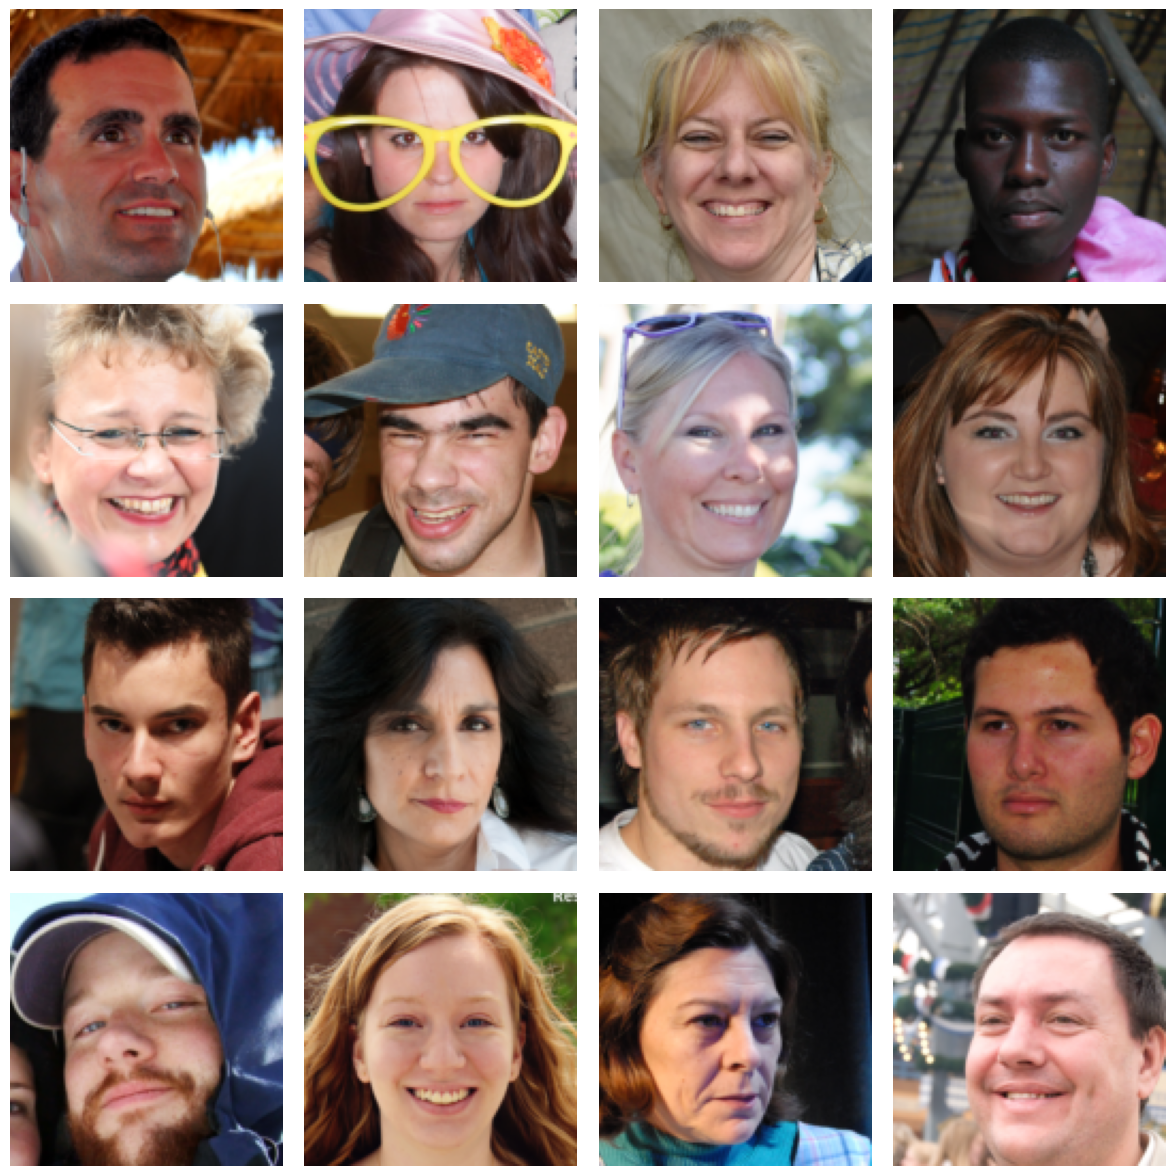

In [ ]:
# Функции визуализации
def denormalize(image_tensor):
    return (image_tensor + 1) / 2

def show_real_images(images, images_number=16, rows=4, columns=4):
    images = denormalize(images.detach().cpu())

    figure, axes = plt.subplots(rows, columns, figsize=(12, 12))

    for i in range(images_number):
        row, col = i // columns, i % columns
        axes[row, col].imshow(images[i].permute(1, 2, 0).numpy())
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

def show_real_batch(data_loader, images_number=16):
    images, _ = next(iter(data_loader))
    images = images[:images_number]
    show_real_images(images, images_number)

show_real_batch(training_loader)

## Часть 2: Построение и обучение модели

Создайте генератор и дискриминатор. Помните, что:

* Дискриминатор принимает на вход изображение (тензор размера `3 x image_size x image_size`) и выдает вероятность того, что изображение настоящее (тензор размера $1$).

* Генератор принимает на вход тензор шумов размера `latent_size x 1 x 1` и генерирует изображение размера `3 x image_size x image_size`.

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.main = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.3),

            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.3),

            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Sigmoid()
        )


    def forward(self, image):
        return self.main(image)


discriminator = Discriminator().to(device)

In [ ]:
latent_size = 256  # Выбрать скрытый размер


class Generator(nn.Module):
    def __init__(self, latent_size=100):
        super(Generator, self).__init__()

        self.main = nn.Sequential(
            nn.ConvTranspose2d(latent_size, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 32, 4, 2, 1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            nn.ConvTranspose2d(32, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )


    def forward(self, latent):
        return self.main(latent)


generator = Generator(latent_size=latent_size).to(device)

In [ ]:
def weights_initialization(module):
    class_name = module.__class__.__name__

    if class_name.find('Conv') != -1:
        nn.init.normal_(module.weight.data, 0.0, 0.02)
    elif class_name.find('BatchNorm') != -1:
        nn.init.normal_(module.weight.data, 1.0, 0.02)
        nn.init.constant_(module.bias.data, 0)

generator.apply(weights_initialization);
discriminator.apply(weights_initialization);

Перейдем теперь к обучению нашего GAN'а. Алгоритм обучения следующий:

1. Обучение дискриминатора:

  * Присваиваем реальным изображениям метку $1$.

  * Присваиваем сгенерированным изображениям метку $0$.

  * Обучаем дискриминатор различать два класса.

2. Обучение генератора:

  * Присваиваем сгенерированным изображениям метку $0$.

  * Предсказываем дискриминатором, реальное это изображение или нет.

В качестве функции потерь используем бинарную кросс-энтропию.

In [ ]:
learning_rate = 0.0002
beta_1 = 0.5
beta_2 = 0.999

model = {
    'discriminator': discriminator,
    'generator': generator
}

criterion = {
    'discriminator': nn.BCELoss(),
    'generator': nn.BCELoss()
}

optimizer = {
    'discriminator': torch.optim.Adam(discriminator.parameters(), lr=learning_rate, betas=(beta_1, beta_2)),
    'generator': torch.optim.Adam(generator.parameters(), lr=learning_rate, betas=(beta_1, beta_2))
}

In [ ]:
def fit(model, criterion, epochs, optimizer, data_loader, latent_size, device):
    # Создайте оптимизаторы и обучите свою GAN
    discriminator = model['discriminator']
    generator = model['generator']

    optimizer_discriminator = optimizer['discriminator']
    optimizer_generator = optimizer['generator']

    discriminator_losses = []
    generator_losses = []

    # Фиксированный латентный вектор для отслеживания прогресса
    fixed_latent = torch.randn(16, latent_size, 1, 1, device=device)

    for epoch in range(epochs):
        discriminator_loss_epoch = 0
        generator_loss_epoch = 0

        for real_images, _ in tqdm(data_loader, desc=f'Эпоха {epoch + 1}/{epochs}'):
            batch_size = real_images.size(0)
            real_images = real_images.to(device)

            real_labels = torch.full((batch_size, 1), 0.9, device=device)
            fake_labels = torch.zeros(batch_size, 1, device=device)

            # Обучение дискриминатора
            optimizer_discriminator.zero_grad()

            # Реальные изображения
            real_predictions = discriminator(real_images)
            real_loss = criterion['discriminator'](real_predictions, real_labels)

            # Фейковые изображения
            latent_vectors = torch.randn(batch_size, latent_size, 1, 1, device=device)
            fake_images = generator(latent_vectors)
            fake_predictions = discriminator(fake_images.detach())
            fake_loss = criterion['discriminator'](fake_predictions, fake_labels)

            discriminator_loss = real_loss + fake_loss
            discriminator_loss.backward()
            optimizer_discriminator.step()

            # Обучение генератора
            optimizer_generator.zero_grad()

            latent_vectors = torch.randn(batch_size, latent_size, 1, 1, device=device)
            fake_images = generator(latent_vectors)
            fake_predictions = discriminator(fake_images)

            generator_loss = criterion['generator'](fake_predictions, real_labels)
            generator_loss.backward()
            optimizer_generator.step()

            discriminator_loss_epoch += discriminator_loss.item()
            generator_loss_epoch += generator_loss.item()

        # Сохраняем средние потери за эпоху
        discriminator_losses.append(discriminator_loss_epoch / len(data_loader))
        generator_losses.append(generator_loss_epoch / len(data_loader))

        # Визуализация прогресса каждые 5 эпох
        if (epoch + 1) % 5 == 0:
            with torch.no_grad():
                generated_images = generator(fixed_latent)
                show_real_images(generated_images, images_number=16)

            print(f'Эпоха {epoch + 1}. Функция потерь дискриминатора: {discriminator_losses[-1]:.4f}, функция потерь генератора: {generator_losses[-1]:.4f}')

    return discriminator_losses, generator_losses

In [ ]:
epochs = 200

discriminator_losses, generator_losses = fit(
    model,
    criterion,
    epochs,
    optimizer,
    training_loader,
    latent_size,
    device
)

Постройте графики функций потерь для генератора и дискриминатора.

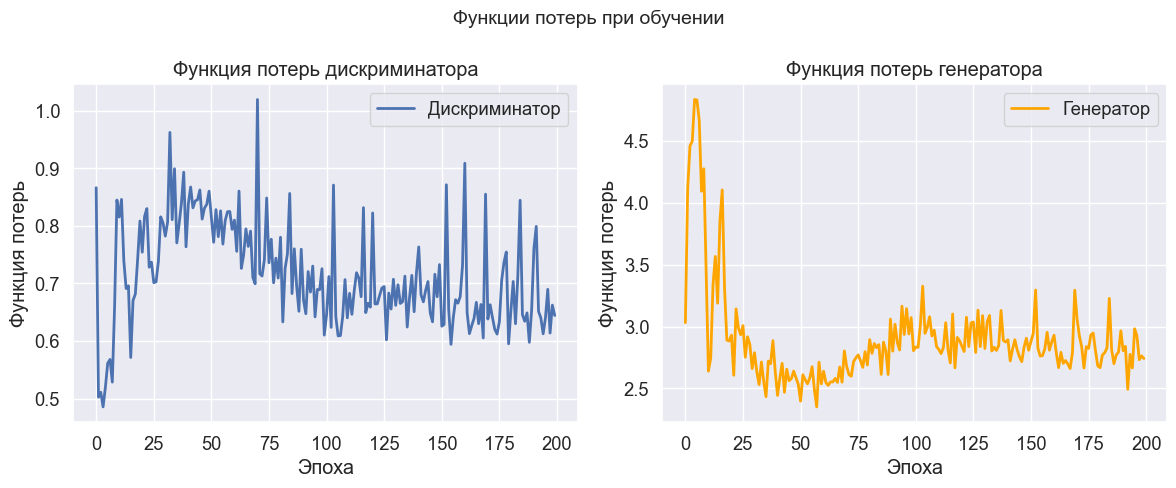

In [ ]:
# Графики функции потерь
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(discriminator_losses, label='Дискриминатор', linewidth=2)
plt.xlabel('Эпоха')
plt.ylabel('Функция потерь')
plt.legend()
plt.title('Функция потерь дискриминатора')

plt.subplot(1, 2, 2)
plt.plot(generator_losses, label='Генератор', linewidth=2, color='orange')
plt.xlabel('Эпоха')
plt.ylabel('Функция потерь')
plt.legend()
plt.title('Функция потерь генератора')

plt.suptitle('Функции потерь при обучении', fontsize=14)
plt.tight_layout()
plt.show()

**Вопрос:**

Что можно сказать об этих графиках?

**Ответ:**

Потери дискриминатора снизились и стабилизировались на низком уровне, что говорит о его способности различать реальные и фейковые изображения. Потери генератора остаются выше, что указывает на сложность обмана дискриминатора.

## Часть 3: Генерация изображений

Теперь давайте оценим качество получившихся изображений. Напишите функцию, которая выводит изображения, сгенерированные нашим генератором.

In [ ]:
def show_images(generated, images_number=16, rows=4, columns=4):
    # Показать сгенерированные изображения
    generated = (generated + 1) / 2
    generated = generated.detach().cpu()

    figure, axes = plt.subplots(rows, columns, figsize=(12, 12))

    for i in range(min(images_number, rows * columns)):
        row, column = i // columns, i % columns
        axes[row, column].imshow(generated[i].permute(1, 2, 0).numpy())
        axes[row, column].axis('off')

    # Скрываем лишние подграфики
    for i in range(images_number, rows * columns):
        row, column = i // columns, i % columns
        axes[row, column].axis('off')

    plt.tight_layout()
    plt.show()

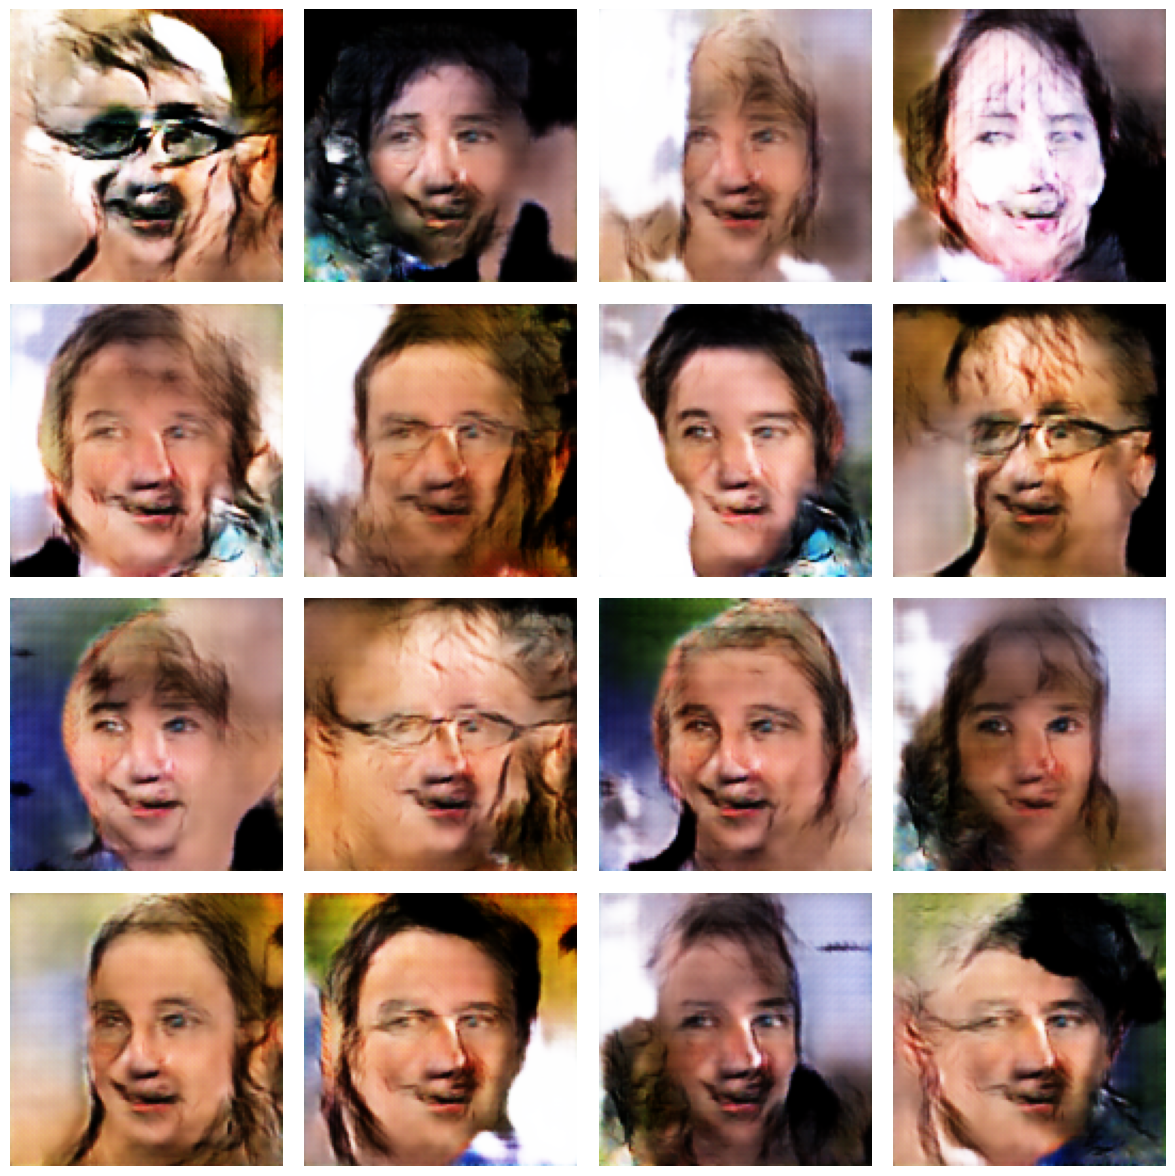

In [ ]:
generator.eval()

with torch.no_grad():
    fixed_latent = torch.randn(16, latent_size, 1, 1, device=device)
    fake_images = generator(fixed_latent)

show_images(fake_images, images_number=16, rows=4, columns=4)

**Вопрос:**

Как вы оцениваете качество полученных изображений?

**Ответ:**

Качество среднее. Генератор создаёт общие очертания лиц (глаза, нос, рот), но изображения размытые, с артефактами и без чётких деталей.

## Часть 4: Оценка качества генерации

### Вычисление точности

Не всегда бывает удобно оценивать качество сгенерированных картинок глазами. В качестве альтернативной метрики предлагается использовать следующий подход:

* Сгенерировать столько же фейковых изображений, сколько есть настоящих в обучающей выборке. Присвоить сгенерированным изображениям − метку $0$, реальным − $1$.

* Применить метод leave-one-out для оценки: обучить классификатор ближайшего соседа (`KNeighborsClassifier` с `n_neighbors = 1`). Предсказывать класс для всех объектов, кроме одного, оценить качество на исключенном объекте. В этом вам поможет `sklearn.model_selection.LeaveOneOut`.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler

import warnings

warnings.filterwarnings('ignore')

# Получаем реальные изображения из датасета
real_images_list = []

for real_images, _ in training_loader:
    real_images_list.append(real_images)

    if len(real_images_list) * batch_size >= 500:
        break

real_images_tensor = torch.cat(real_images_list, dim=0)[:500]
real_features = real_images_tensor.view(real_images_tensor.size(0), -1).cpu().numpy()
real_labels = np.ones(len(real_features))

# Генерируем фейковые изображения
generator.eval()
fake_features_list = []

with torch.no_grad():
    for _ in range(0, 500, batch_size):
        current_batch_size = min(batch_size, 500 - len(fake_features_list) * batch_size)

        if current_batch_size <= 0:
            break

        latent_vectors = torch.randn(current_batch_size, latent_size, 1, 1, device=device)
        fake_images = generator(latent_vectors)
        fake_features_list.append(fake_images.view(current_batch_size, -1).cpu().numpy())

fake_features = np.concatenate(fake_features_list, axis=0)[:500]
fake_labels = np.zeros(len(fake_features))

if real_features.shape[1] != fake_features.shape[1]:
    minimum_dimension = min(real_features.shape[1], fake_features.shape[1])
    real_features = real_features[:, :minimum_dimension]
    fake_features = fake_features[:, :minimum_dimension]

# Объединяем данные
features = np.concatenate([real_features, fake_features])
labels = np.concatenate([real_labels, fake_labels])

# Нормализация признаков
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

knn = KNeighborsClassifier(n_neighbors=1, n_jobs=1)
loo = LeaveOneOut()

correct_predictions = 0
total_predictions = 0

for training_index, testing_index in loo.split(features_scaled):
    features_training, features_testing = features_scaled[training_index], features_scaled[testing_index]
    labels_training, labels_testing = labels[training_index], labels[testing_index]

    knn.fit(features_training, labels_training)
    prediction = knn.predict(features_testing)

    if prediction == labels_testing:
        correct_predictions += 1

    total_predictions += 1

accuracy = correct_predictions / total_predictions

print(f'Точность: {accuracy:.4f}')

Точность: 0.9740


**Вопрос:**

Что можно сказать о полученном результате? Какого значения точности следует ожидать и почему?

**Ответ:**

Точность $0.9740$ означает, что сгенерированные изображения всё ещё заметно отличаются от реальных. В идеале, если генератор идеально подделывает изображения, точность должна стремиться к $0.5$ (случайное угадывание).

### Визуализация распределений

Давайте оценим, насколько похожи распределения настоящих и фейковых изображений. Для этого воспользуйтесь методом снижения размерности (например, t-SNE) и изобразите на графике разным цветом точки, соответствующие реальным и сгенерированным изображения.

Реальные образцы: (200, 49152)
Фейковые образцы: (200, 49152)


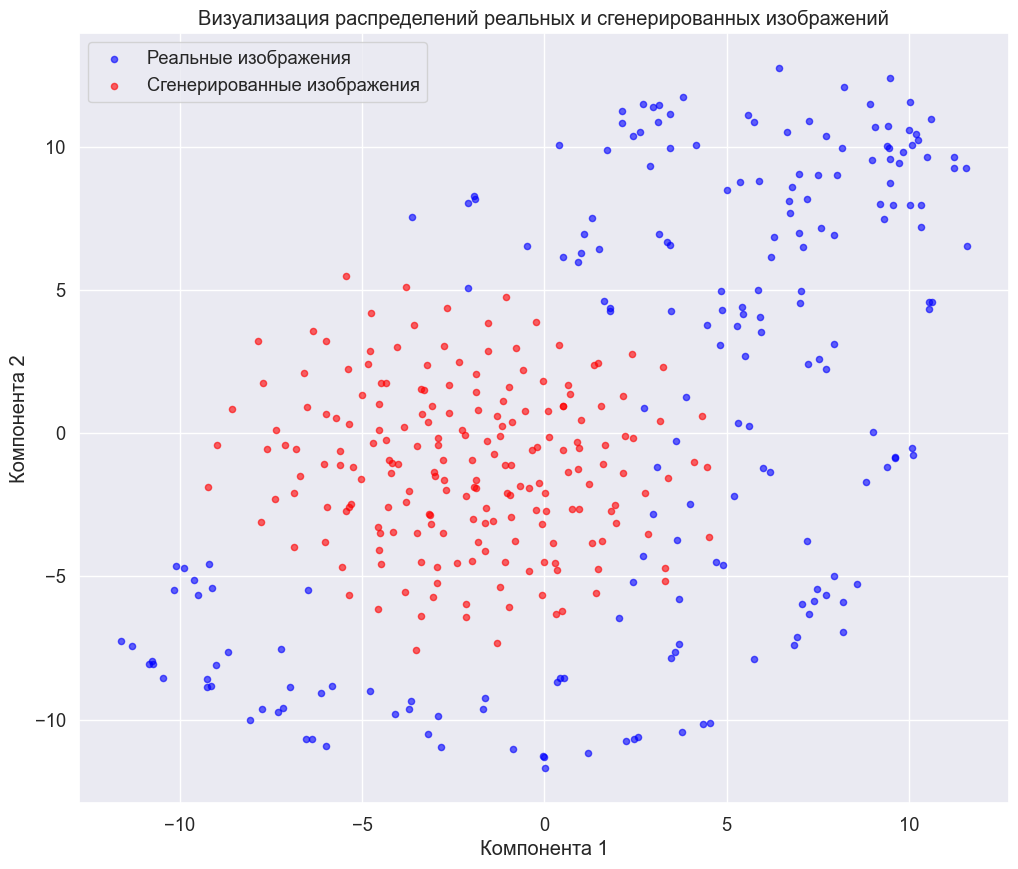

In [ ]:
from sklearn.manifold import TSNE

# Берем по 200 изображений каждого типа для визуализации
sample_size = 200
real_samples = real_features[:sample_size]
fake_samples = fake_features[:sample_size]

print(f'Реальные образцы: {real_samples.shape}')
print(f'Фейковые образцы: {fake_samples.shape}')

# Объединяем данные
features_combined = np.vstack([real_samples, fake_samples])
labels_combined = np.concatenate([np.ones(sample_size), np.zeros(sample_size)])

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_jobs=1)
features_2d = tsne.fit_transform(features_combined)

# Визуализация
plt.figure(figsize=(12, 10))

real_mask = labels_combined == 1
fake_mask = labels_combined == 0

plt.scatter(features_2d[real_mask, 0], features_2d[real_mask, 1], c='blue', label='Реальные изображения', alpha=0.6, s=20)
plt.scatter(features_2d[fake_mask, 0], features_2d[fake_mask, 1], c='red', label='Сгенерированные изображения', alpha=0.6, s=20)

plt.xlabel('Компонента 1')
plt.ylabel('Компонента 2')
plt.legend()
plt.title('Визуализация распределений реальных и сгенерированных изображений')
plt.show()

**Вопрос:**

Почему получен такой результат? Прокомментируйте его.

**Ответ:**

 На визуализации видно частичное перекрытие синих (реальные) и красных (сгенерированные) точек, но кластеры разделены. Это соответствует точности $0.9740$: генератор научился некоторым закономерностям, но ещё не полностью имитирует распределение реальных данных. Полное перекрытие означало бы точность около $0.5$.